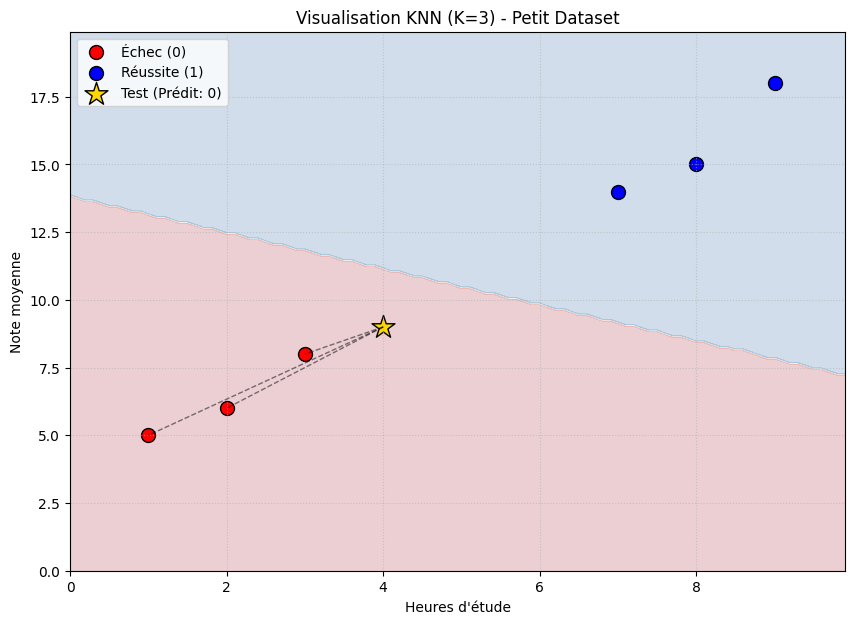

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# =========================================================
# 1.DE DONNÉES
# =========================================================
X_train = np.array([
    [1, 5],   # Étudiant A -> Échec (0)
    [2, 6],   # Étudiant B -> Échec (0)
    [3, 8],   # Étudiant C -> Échec (0)
    [8, 15],  # Étudiant D -> Réussite (1)
    [9, 18],  # Étudiant E -> Réussite (1)
    [7, 14]   # Étudiant F -> Réussite (1)
])
y_train = np.array([0, 0, 0, 1, 1, 1])

# Point de test
x_test = np.array([4, 9])
K = 3

# =========================================================
# 2. FONCTION KNN (FROM SCRATCH)
# =========================================================

def knn_predict(X, y, point, k=3):
    # Calcul des distances Euclidiennes
    distances = [np.sqrt(np.sum((point - x_i)**2)) for x_i in X]
    # Tri et récupération des indices des plus proches
    indices_voisins = np.argsort(distances)[:k]
    classes_voisins = y[indices_voisins]
    vote = Counter(classes_voisins).most_common(1)[0][0]
    return vote, indices_voisins

# =========================================================
# 3. VISUALISATION DES RÉSULTATS
# =========================================================

def visualiser_knn(X, y, point_test, k):
    resultat, indices_v = knn_predict(X, y, point_test, k)

    plt.figure(figsize=(10, 7))
    x_min, x_max = 0, 10
    y_min, y_max = 0, 20
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_preds = [knn_predict(X, y, p, k)[0] for p in grid_points]
    grid_preds = np.array(grid_preds).reshape(xx.shape)
    plt.contourf(xx, yy, grid_preds, alpha=0.2, cmap='RdBu')
    plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', s=100, label='Échec (0)', edgecolor='black')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', s=100, label='Réussite (1)', edgecolor='black')
    couleur_test = 'blue' if resultat == 1 else 'red'
    plt.scatter(point_test[0], point_test[1], color='gold', marker='*', s=300,
                label=f'Test (Prédit: {resultat})', edgecolor='black')
    for idx in indices_v:
        plt.plot([point_test[0], X[idx, 0]], [point_test[1], X[idx, 1]],
                 'k--', alpha=0.5, linewidth=1)
    plt.title(f"Visualisation KNN (K={k}) - Petit Dataset")
    plt.xlabel("Heures d'étude")
    plt.ylabel("Note moyenne")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# =========================================================
# 4. EXÉCUTION
# =========================================================
visualiser_knn(X_train, y_train, x_test, K)

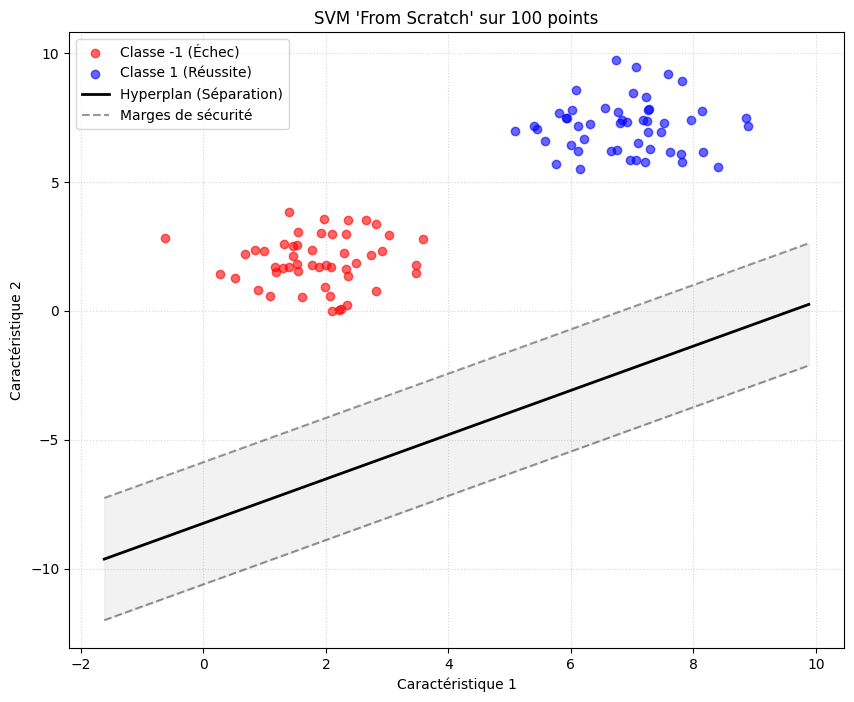

Coefficients (w) : [0.36220638 0.42185474]
Biais (b) : 3.4749999999997283


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. GÉNÉRATION D'UN GRAND JEU DE DONNÉES SYNTHÉTIQUE
# =========================================================

def generer_data(n_points=100):
    np.random.seed(42)

    # Classe -1 : Points centrés autour de [2, 2]
    X1 = np.random.randn(n_points // 2, 2) + np.array([2, 2])
    y1 = np.ones(n_points // 2) * -1

    # Classe 1 : Points centrés autour de [7, 7]
    X2 = np.random.randn(n_points // 2, 2) + np.array([7, 7])
    y2 = np.ones(n_points // 2)

    X = np.vstack((X1, X2))
    y = np.hstack((y1, y2))

    return X, y

# =========================================================
# 2. ENTRAÎNEMENT SVM (VERSION GRADIENT DESCENT)
# =========================================================

def entrainer_svm(X, y, lr=0.001, lambda_param=0.01, n_iters=1000):
    m, n = X.shape
    w = np.zeros(n)
    b = 0

    for _ in range(n_iters):
        for idx, x_i in enumerate(X):
            # Condition Hinge Loss : y_i * (w.x_i + b) >= 1
            condition = y[idx] * (np.dot(x_i, w) - b) >= 1

            if condition:
                # Si le point est bien classé
                w -= lr * (2 * lambda_param * w)
            else:
                # Si le point est un vecteur de support ou mal classé
                w -= lr * (2 * lambda_param * w - np.dot(x_i, y[idx]))
                b -= lr * y[idx]

    return w, b

# =========================================================
# 3. VISUALISATION DES RÉSULTATS
# =========================================================

def visualiser_grand_svm(X, y, w, b):
    plt.figure(figsize=(10, 8))

    plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', alpha=0.6, label='Classe -1 (Échec)')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', alpha=0.6, label='Classe 1 (Réussite)')

    x_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
    y_vals = (w[0] * x_vals - b) / w[1]

    marge_sup = (w[0] * x_vals - b + 1) / w[1]
    marge_inf = (w[0] * x_vals - b - 1) / w[1]

    plt.plot(x_vals, y_vals, 'k', linewidth=2, label='Hyperplan (Séparation)')
    plt.plot(x_vals, marge_sup, 'k--', alpha=0.4, label='Marges de sécurité')
    plt.plot(x_vals, marge_inf, 'k--', alpha=0.4)
    plt.fill_between(x_vals, marge_inf, marge_sup, color='gray', alpha=0.1)
    plt.title(f"SVM 'From Scratch' sur {len(y)} points")
    plt.xlabel("Caractéristique 1")
    plt.ylabel("Caractéristique 2")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()

# =========================================================
# 4. EXÉCUTION
# =========================================================

# 1. Génération des données
X_data, y_data = generer_data(100)

# 2. Entraînement
poids, biais = entrainer_svm(X_data, y_data, lr=0.001, n_iters=1500)

# 3. Visualisation
visualiser_grand_svm(X_data, y_data, poids, biais)

print(f"Coefficients (w) : {poids}")
print(f"Biais (b) : {biais}")